# Attention-based explanations for the IF/THEN span tagger

`train_span_classifier.py` fine-tunes a LoRA adapter on ParsBERT (`HooshvareLab/bert-fa-zwnj-base`)
for per-token BIO tagging (`O / B-IF / I-IF / B-THEN / I-THEN`). This notebook is a first pass at
the "look at attention scores to explain decisions" item from the README's further-work list.

**Idea.** Each token's classification logits come from its final-layer hidden state, which self-attention
builds as a weighted mix of every other token's representation. So for a token the model tags as, say,
`B-IF`, the self-attention weights *from that token's position* (last layer, averaged over heads) tell us
which other tokens fed into the representation the classifier head actually saw -- a cheap, model-native
saliency signal (not a causal explanation: attention weight is not the same as attribution, see caveats
at the end).

**What this notebook does:**
1. Reloads the trained adapter and reproduces the exact test split `train_span_classifier.py` used
   (same seed, same stratified split).
2. Samples 20 test sentences, 10 with a real IF/THEN span ("positive": `prompt_variant` marked/unmarked)
   and 10 without one ("negative": every token `O`).
3. Runs each sentence through the model with `output_attentions=True`, aggregates subword attention up
   to word level, and for every word the model *predicts* as part of a span, lists the words it attended
   to most.
4. Plots a word-by-word attention heatmap per sentence, with predicted tags on the axis.

**Requirements:** `pip install torch transformers peft matplotlib` (optionally `arabic_reshaper` +
`python-bidi` for correctly shaped Persian text inside plots, as in `parsbert_embeddings.ipynb`).

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from peft import PeftModel
from transformers import AutoModelForTokenClassification, AutoTokenizer

from persian_display import display_persian
from span_classifier_common import BIO_ID2LABEL, BIO_LABEL2ID, BIO_TAGS, MAX_LENGTH, MODEL_NAME
from train_span_classifier import build_split_datasets

try:
    import arabic_reshaper
    from bidi.algorithm import get_display

    def shape_for_plot(text):
        return get_display(arabic_reshaper.reshape(text))
except ImportError:
    def shape_for_plot(text):
        return text

## Load the trained adapter

Same loading path as `span_classifier_ui.py`, plus `output_attentions=True`.

In [2]:
ADAPTER_DIR = Path("checkpoints/parsbert-lora-span-classifier/final")

tokenizer = AutoTokenizer.from_pretrained(str(ADAPTER_DIR))
if not tokenizer.is_fast:
    raise RuntimeError(f"{MODEL_NAME} did not load a fast (Rust) tokenizer, which word_ids() needs.")

base_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(BIO_TAGS),
    id2label=BIO_ID2LABEL,
    label2id=BIO_LABEL2ID,
    attn_implementation="eager",  # SDPA/flash kernels don't materialize attention weights
    output_attentions=True,
)
model = PeftModel.from_pretrained(base_model, str(ADAPTER_DIR))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
n_layers = model.config.num_hidden_layers
n_heads = model.config.num_attention_heads
print(f"Loaded adapter from {ADAPTER_DIR} on {device}: {n_layers} layers x {n_heads} heads")

Loaded adapter from checkpoints\parsbert-lora-span-classifier\final on cpu: 12 layers x 12 heads


## Reproduce the test split

`train_span_classifier.py`'s `build_split_datasets` does a seeded 60/20/20 train/val/test split,
stratified by `prompt_variant` (`marked` / `unmarked` / `negative`). Calling it again with the same
default paths and seed reproduces the exact same test set the training run reported metrics on.

In [3]:
splits = build_split_datasets("persian_conditionals_bio.jsonl", "persian_negatives_bio.jsonl", seed=42)
test = splits["test"]
print(f"Test split: {len(test)} sentences")

Split sizes:
  train      n=1200  {'marked': 300, 'negative': 600, 'unmarked': 300}
  validation n=400   {'negative': 200, 'marked': 100, 'unmarked': 100}
  test       n=400   {'unmarked': 100, 'negative': 200, 'marked': 100}
Test split: 400 sentences


## Sample 20 examples, 10 per class

"Positive" = at least one non-`O` gold tag (a real IF/THEN span, marked or unmarked). "Negative" = every
gold tag is `O`. 10 of each, drawn with a fixed RNG for reproducibility.

In [4]:
def is_positive(tags):
    return any(t != "O" for t in tags)


positive_idx = [i for i, tags in enumerate(test["tags"]) if is_positive(tags)]
negative_idx = [i for i, tags in enumerate(test["tags"]) if not is_positive(tags)]
print(f"Positive (has IF/THEN span) in test: {len(positive_idx)}")
print(f"Negative (all O) in test:            {len(negative_idx)}")

rng = np.random.default_rng(42)
N_PER_CLASS = 10
sample_idx = list(rng.choice(positive_idx, size=N_PER_CLASS, replace=False)) + list(
    rng.choice(negative_idx, size=N_PER_CLASS, replace=False)
)
sample_examples = [{"tokens": test[i]["tokens"], "tags": test[i]["tags"], "positive": i in positive_idx} for i in sample_idx]
print(f"Sampled {len(sample_examples)} examples ({N_PER_CLASS} positive + {N_PER_CLASS} negative)")

Positive (has IF/THEN span) in test: 200
Negative (all O) in test:            200
Sampled 20 examples (10 positive + 10 negative)


## Predict + aggregate attention to word level

- Run the model with `output_attentions=True`; take the **last layer**, averaged over heads -- the
  attention pattern that most directly shaped the hidden state the classification head consumed.
- Subwords are collapsed to words: a query word's row is the *first-subword* row (the one whose hidden
  state actually carries the label, per `tokenize_and_align_labels`'s `-100` masking of continuation
  subwords during training); a key word's column is the **sum** of its subwords' columns (attention
  mass is additive over keys).
- `[CLS]`/`[SEP]` are kept out of the "top attended words" report (they're attention sinks in BERT and
  rarely informative) but shown in the heatmap for completeness.

In [5]:
@torch.no_grad()
def run_example(tokens):
    encoded = tokenizer(
        tokens, truncation=True, max_length=MAX_LENGTH, is_split_into_words=True, return_tensors="pt"
    ).to(device)
    output = model(**encoded, output_attentions=True)
    pred_ids = output.logits[0].argmax(dim=-1).tolist()
    word_ids = encoded.word_ids(batch_index=0)

    # last layer, mean over heads: (seq, seq)
    last_layer_attn = output.attentions[-1][0].mean(dim=0).cpu().numpy()

    n_words = len(tokens)
    first_subword_of = {}  # word_idx -> subword position of its first subword
    subwords_of = {i: [] for i in range(n_words)}
    for pos, w in enumerate(word_ids):
        if w is None:
            continue
        subwords_of[w].append(pos)
        if w not in first_subword_of:
            first_subword_of[w] = pos

    special_positions = [pos for pos, w in enumerate(word_ids) if w is None]

    # word x word attention: query = first-subword row, key = summed subword columns
    n_seq = last_layer_attn.shape[0]
    word_attn = np.zeros((n_words, n_words))
    for qw in range(n_words):
        qpos = first_subword_of[qw]
        for kw in range(n_words):
            word_attn[qw, kw] = last_layer_attn[qpos, subwords_of[kw]].sum()

    pred_tags = ["O"] * n_words
    for w, pos in first_subword_of.items():
        pred_tags[w] = BIO_ID2LABEL[pred_ids[pos]]

    return {
        "tokens": tokens,
        "pred_tags": pred_tags,
        "word_attn": word_attn,
        "seq_attn_full": last_layer_attn,
        "word_ids": word_ids,
        "special_positions": special_positions,
    }


def is_punct_token(tok):
    return not any(ch.isalnum() for ch in tok)


def top_attended_words(result, query_word_idx, k=3, exclude_punct=False):
    tokens = result["tokens"]
    row = result["word_attn"][query_word_idx].copy()
    row[query_word_idx] = -1  # exclude self
    if exclude_punct:
        for i, tok in enumerate(tokens):
            if is_punct_token(tok):
                row[i] = -1
    top_idx = np.argsort(row)[::-1][:k]
    return [(tokens[i], float(result["word_attn"][query_word_idx, i])) for i in top_idx if row[i] >= 0]

## Run over the 20 sampled sentences and report top-attended words per predicted span token

In [6]:
results = []
for ex in sample_examples:
    r = run_example(ex["tokens"])
    r["gold_positive"] = ex["positive"]
    r["gold_tags"] = ex["tags"]
    results.append(r)

for i, r in enumerate(results):
    text = " ".join(r["tokens"])
    label = "POSITIVE (gold has IF/THEN span)" if r["gold_positive"] else "NEGATIVE (gold all O)"
    display_persian(f"\n[{i}] {label}")
    display_persian(f"  text: {text}")
    print("  predicted tags:", list(zip(r["tokens"], r["pred_tags"])))

    span_word_idxs = [w for w, tag in enumerate(r["pred_tags"]) if tag != "O"]
    if not span_word_idxs:
        print("  (model predicted no IF/THEN span -- nothing to explain)")
        continue
    for w in span_word_idxs:
        top_any = top_attended_words(r, w, k=1)
        top_content = top_attended_words(r, w, k=3, exclude_punct=True)
        sink = f"{top_any[0][0]}({top_any[0][1]:.2f})" if top_any and is_punct_token(top_any[0][0]) else None
        content_str = ", ".join(f"{tok}({wt:.2f})" for tok, wt in top_content) or "(none)"
        sink_str = f", sink={sink}" if sink else ""
        display_persian(f"  {r['tokens'][w]!r:>14} [{r['pred_tags'][w]}] top content words: {content_str}{sink_str}")


[0] POSITIVE (gold has IF/THEN span)
  text: یه کم ورزش کن ، حالت بهتر میشه .
  predicted tags: [('یه', 'B-IF'), ('کم', 'I-IF'), ('ورزش', 'I-IF'), ('کن', 'I-IF'), ('،', 'O'), ('حالت', 'B-THEN'), ('بهتر', 'I-THEN'), ('می\u200cشه', 'I-THEN'), ('.', 'O')]
            'یه' [B-IF] top content words: بهتر(0.04), میشه(0.04), کن(0.03), sink=.(0.48)
            'کم' [I-IF] top content words: یه(0.05), ورزش(0.05), کن(0.04), sink=.(0.65)
          'ورزش' [I-IF] top content words: کن(0.07), کم(0.05), میشه(0.04), sink=.(0.61)
            'کن' [I-IF] top content words: میشه(0.05), ورزش(0.03), یه(0.03), sink=.(0.63)
          'حالت' [B-THEN] top content words: بهتر(0.06), میشه(0.04), یه(0.02), sink=.(0.22)
          'بهتر' [I-THEN] top content words: حالت(0.09), میشه(0.06), یه(0.01), sink=.(0.67)
    'میشه' [I-THEN] top content words: بهتر(0.05), حالت(0.04), یه(0.02), sink=.(0.68)

[1] POSITIVE (gold has IF/THEN span)
  text: کاهش دمای هوا رخ دهد ، مصرف انرژی افزایش خواهد یافت .
  predicted tags: [(

## Heatmaps

One word x word attention heatmap per sentence (last layer, mean over heads), y-axis rows are query
words (colored by predicted tag), x-axis columns are key words attended to. `[CLS]`/`[SEP]` included.

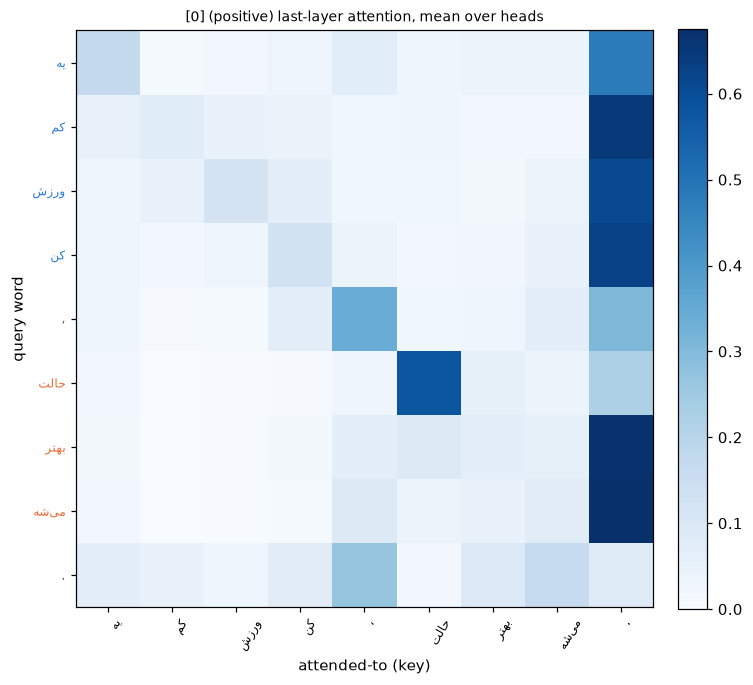

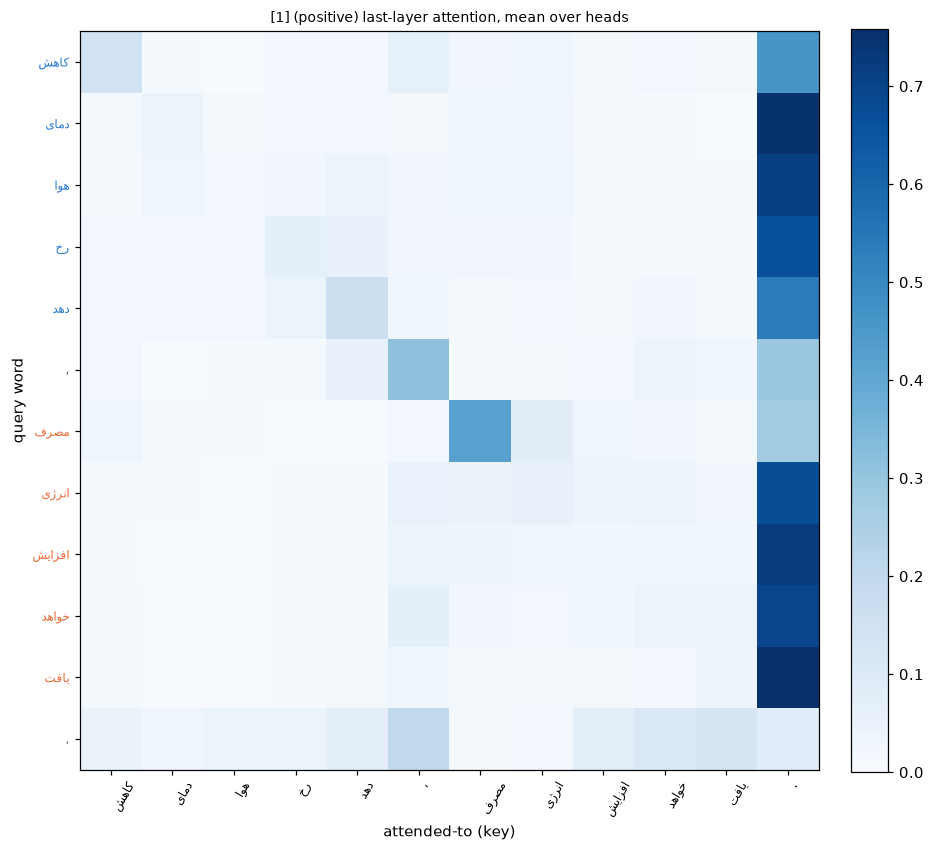

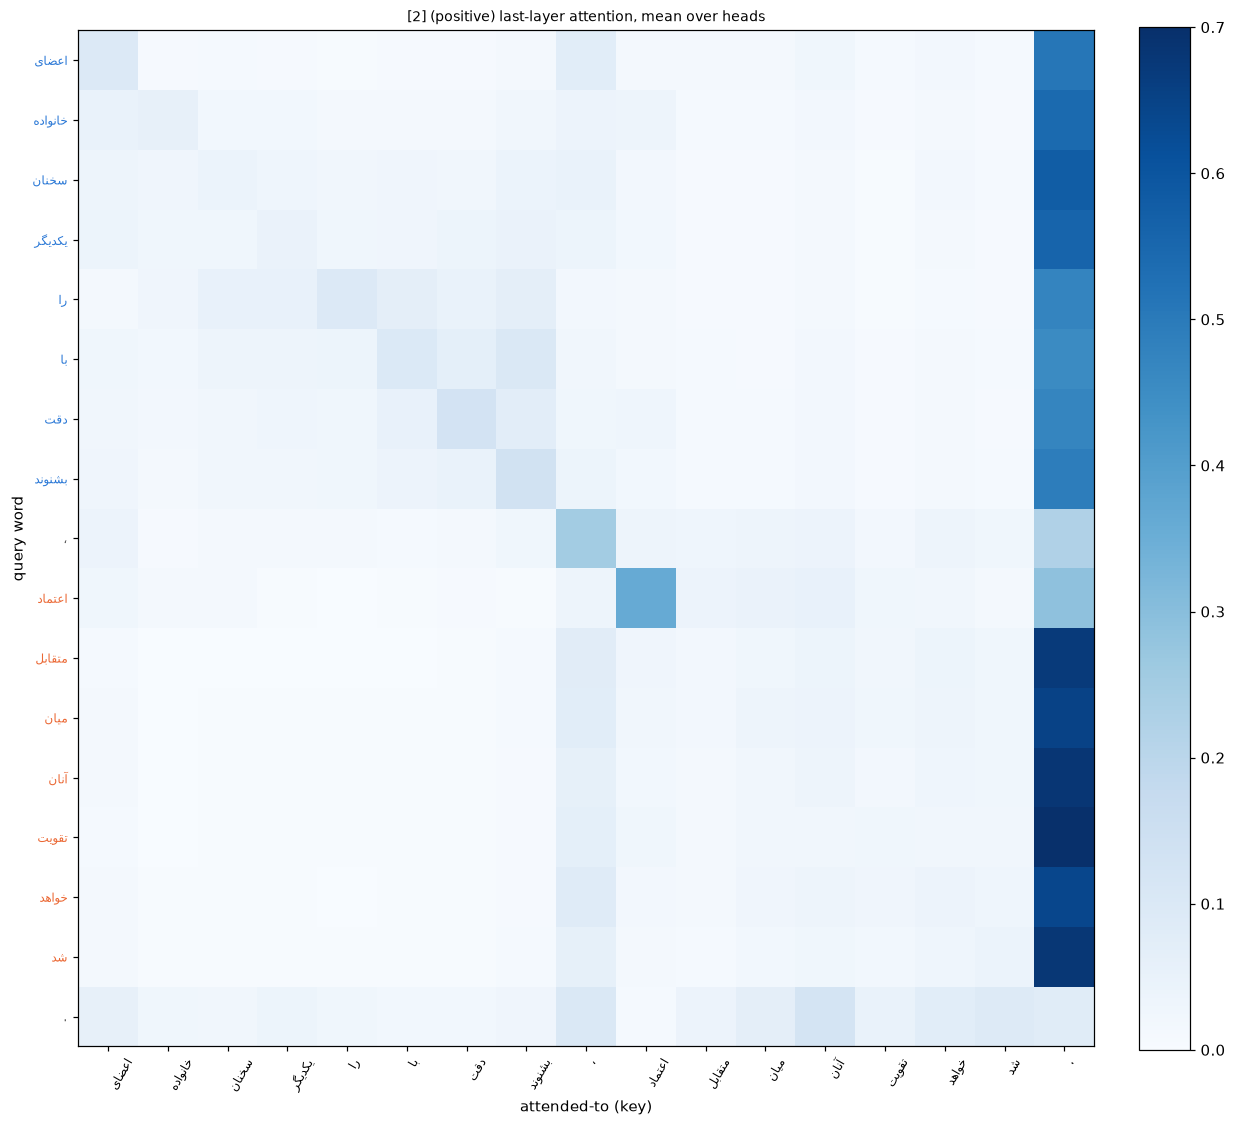

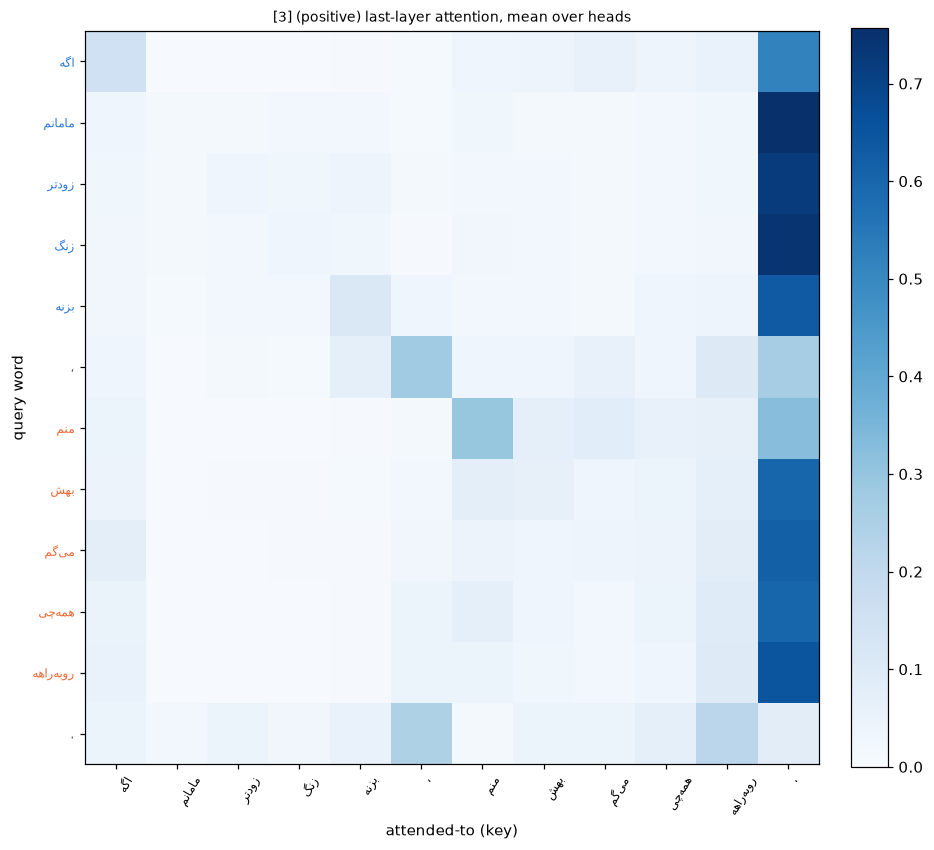

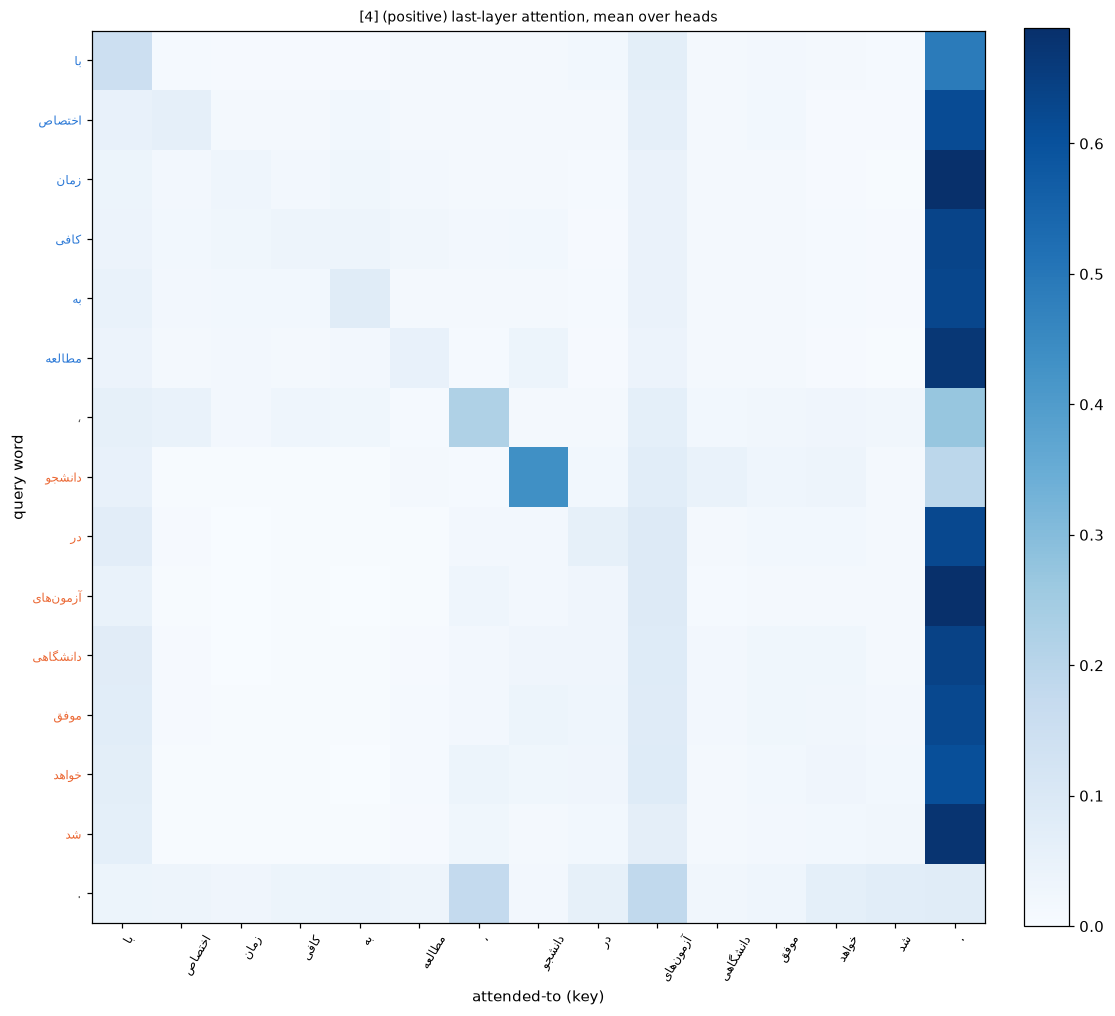

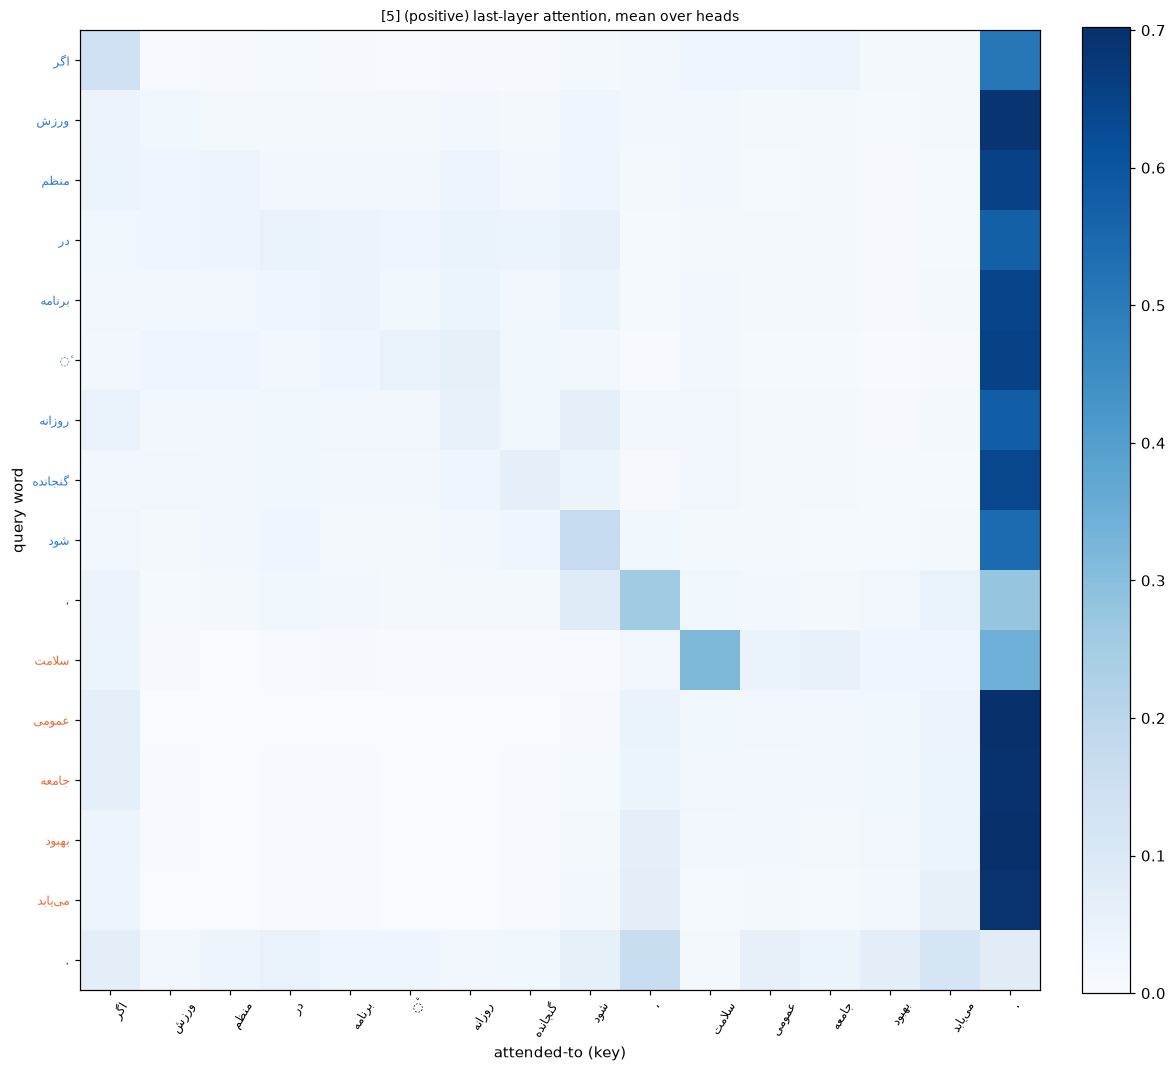

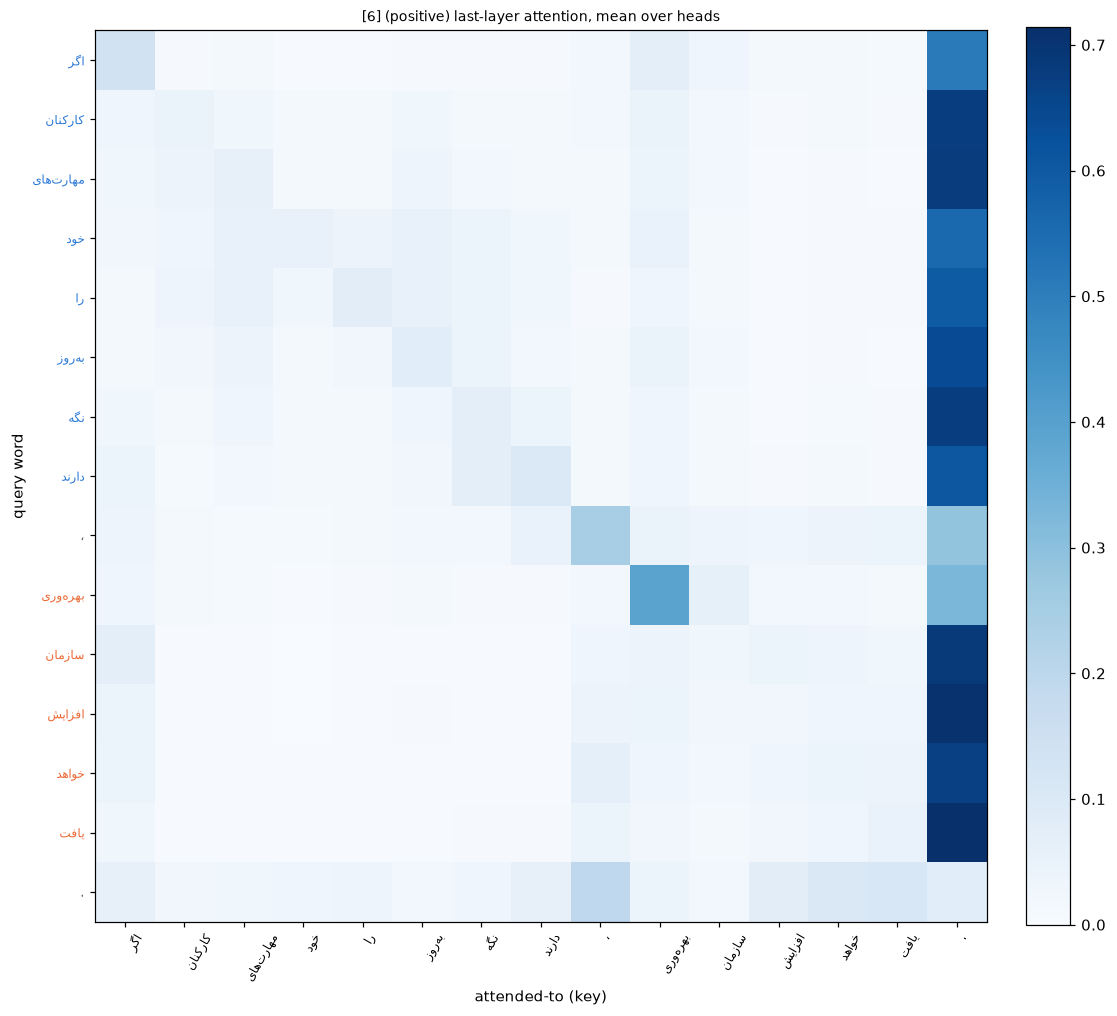

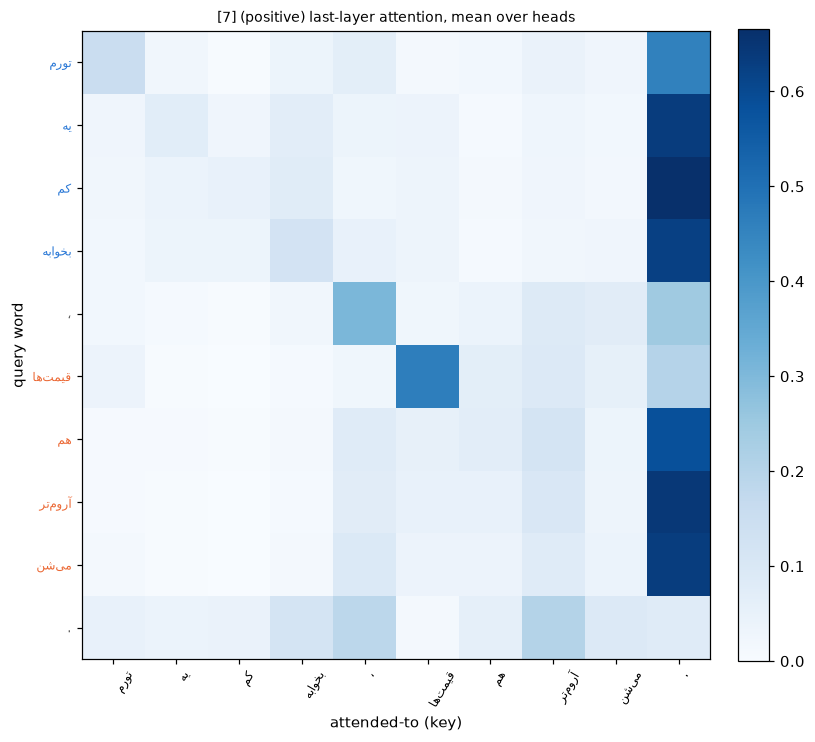

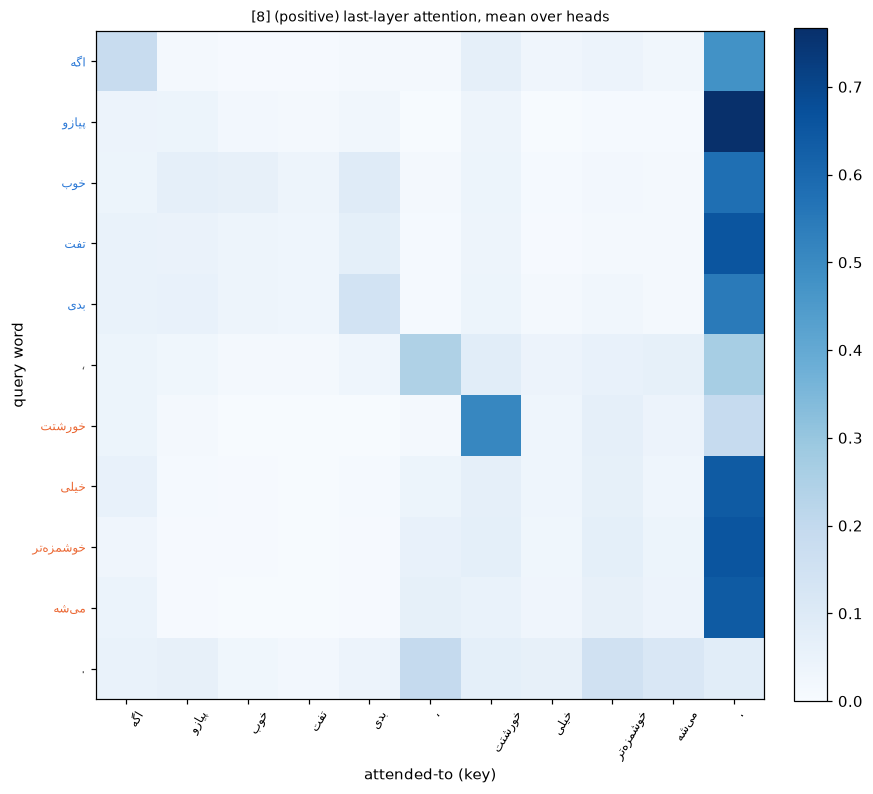

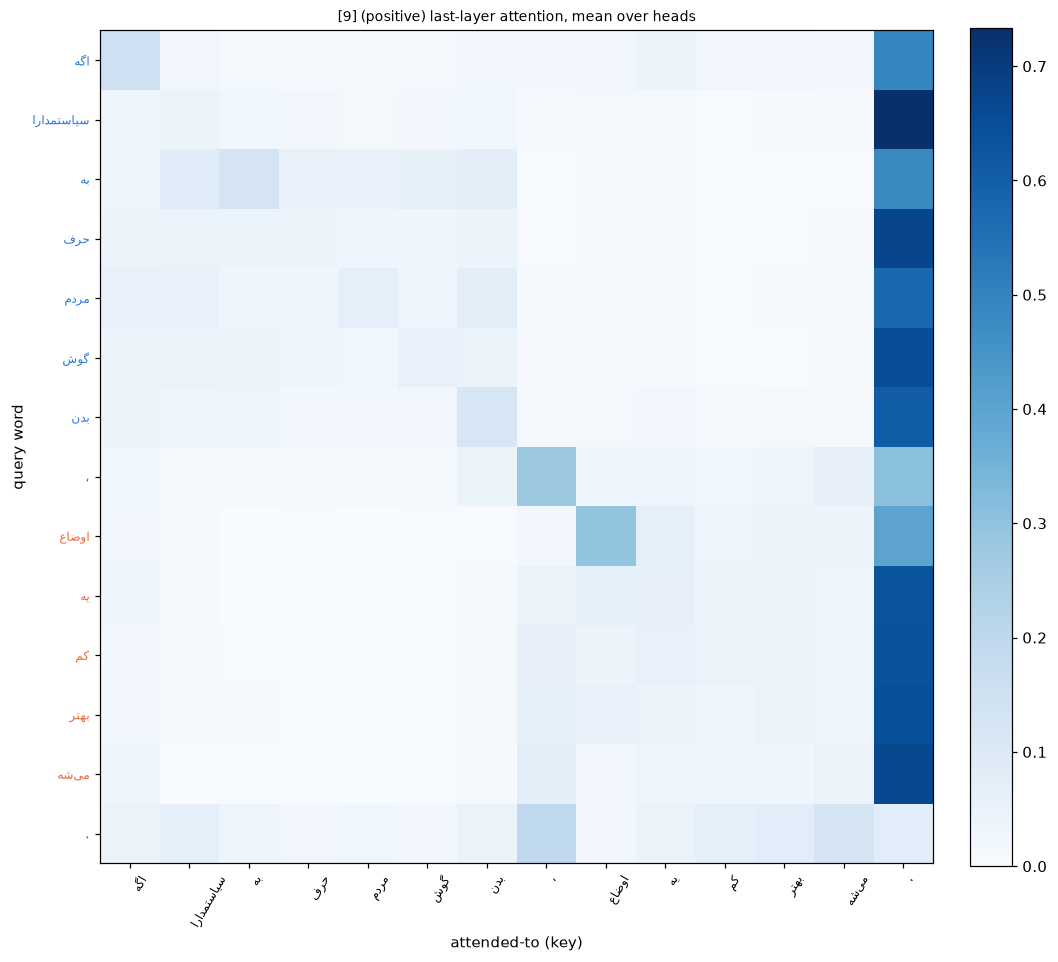

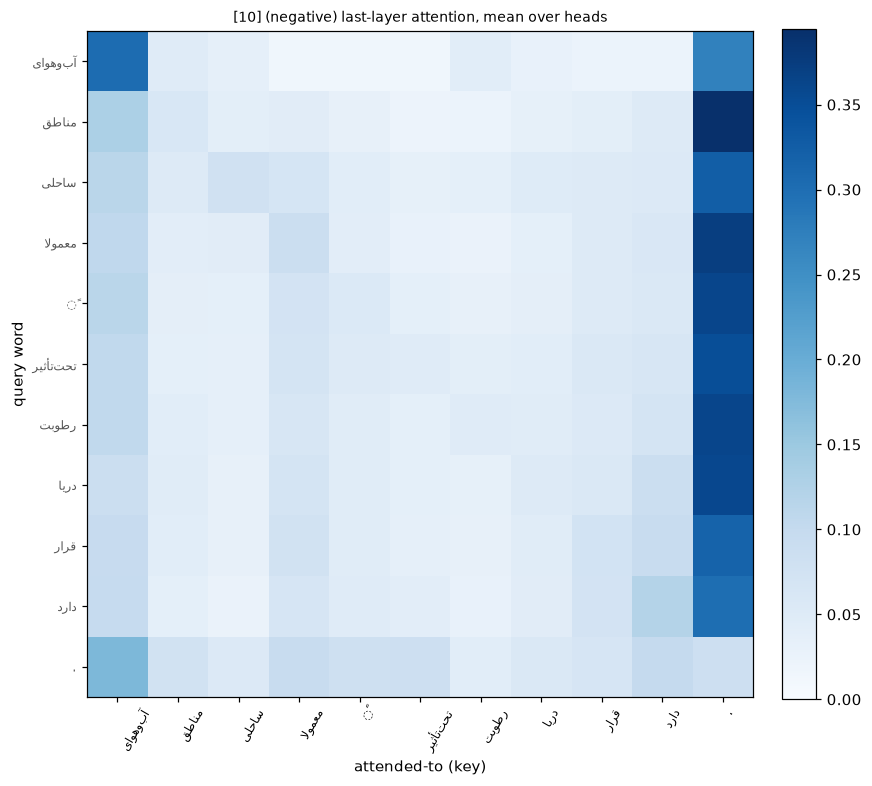

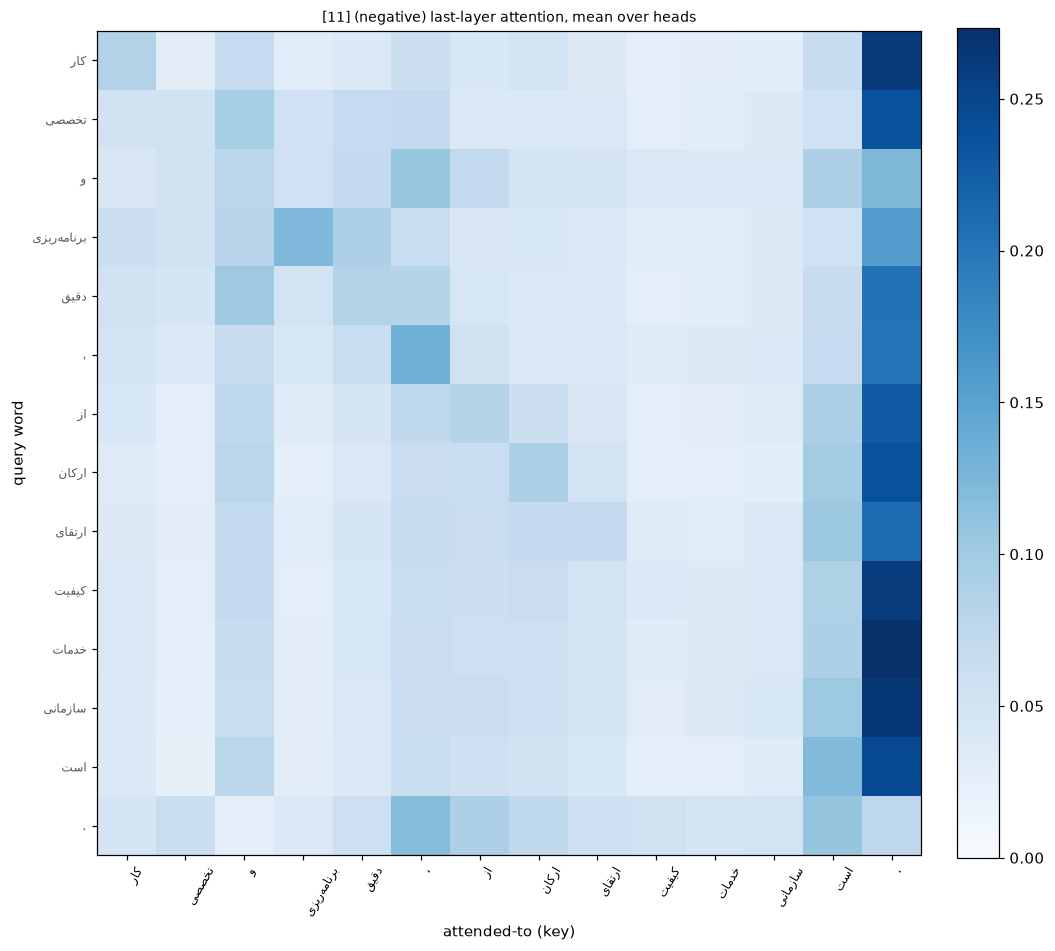

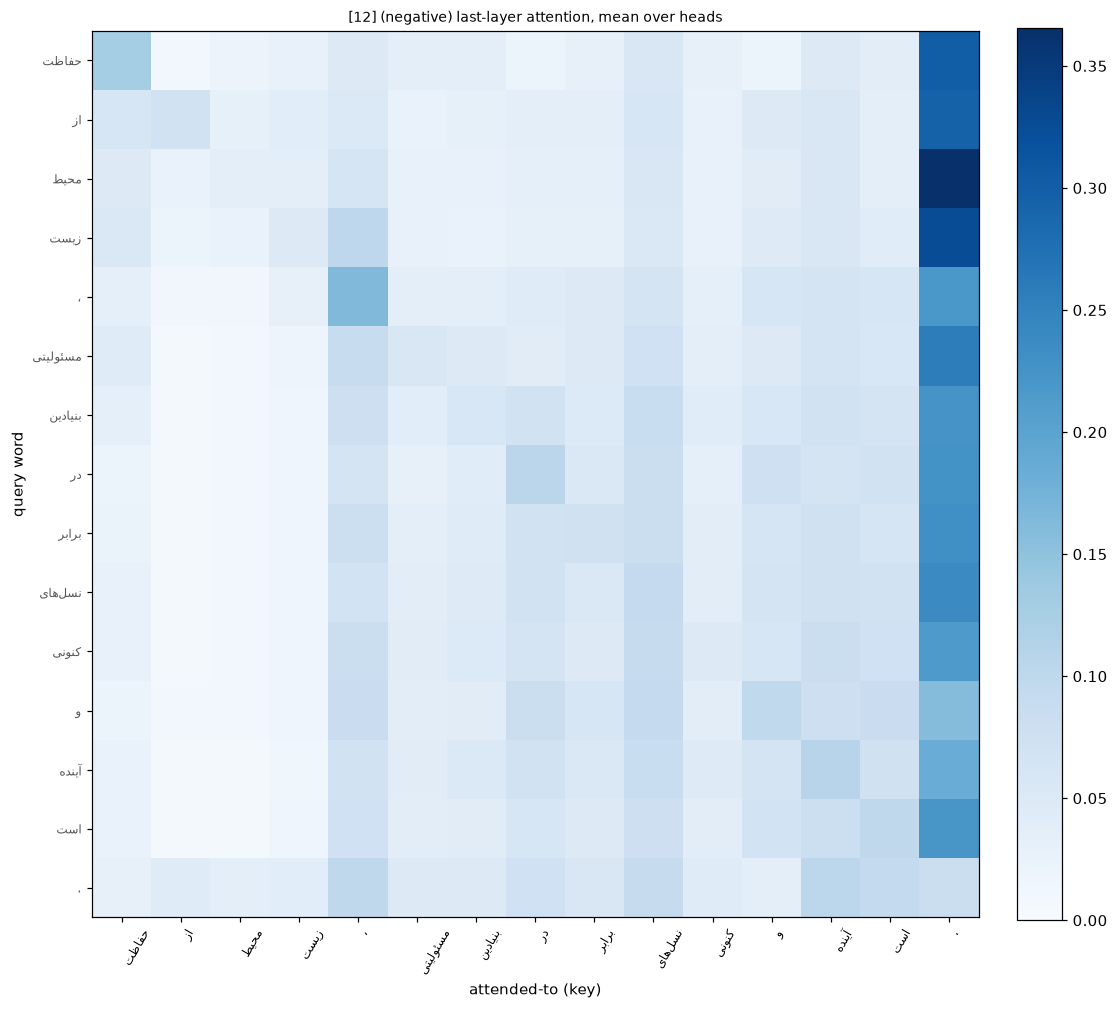

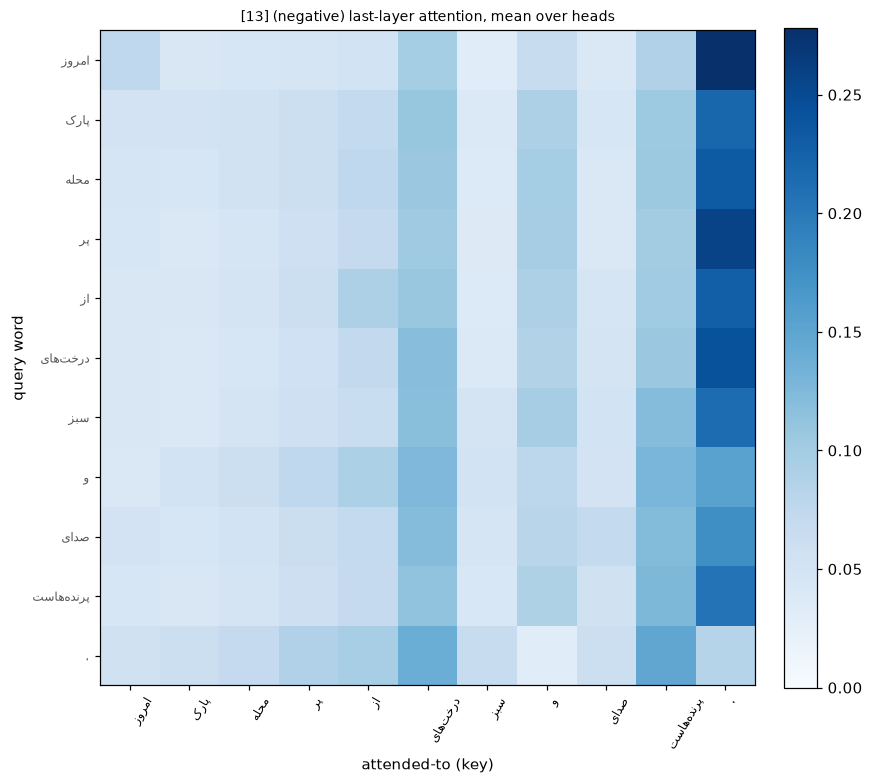

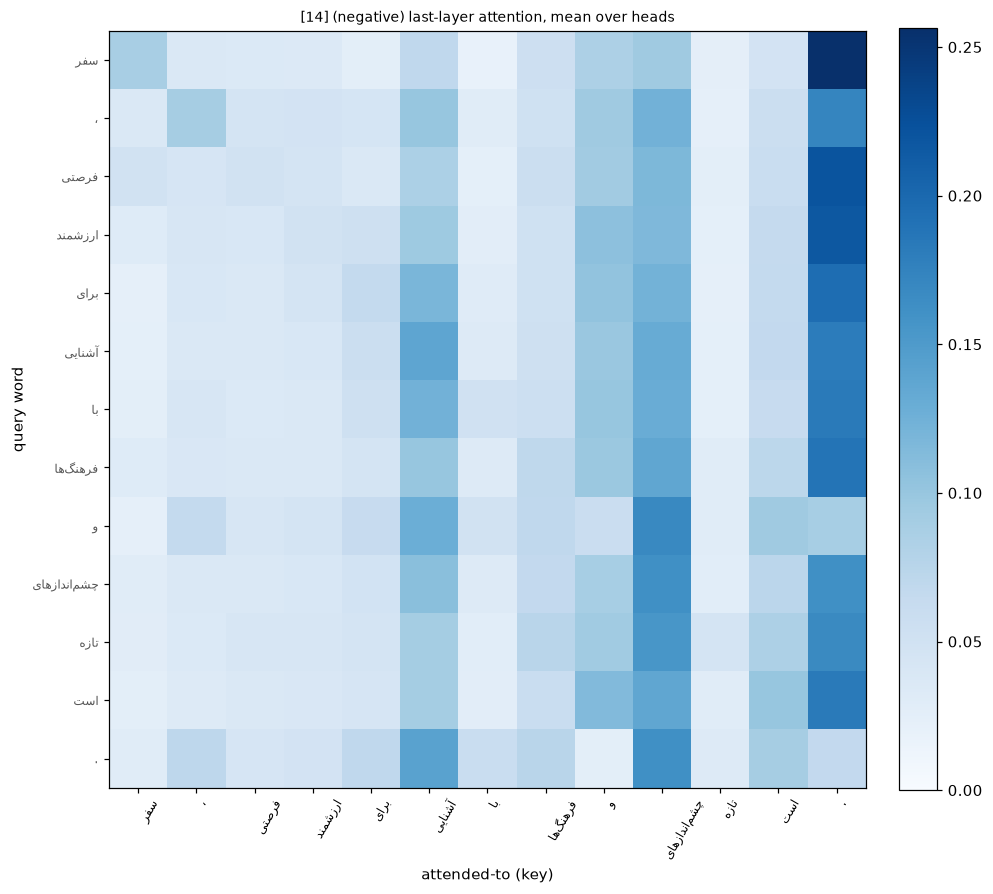

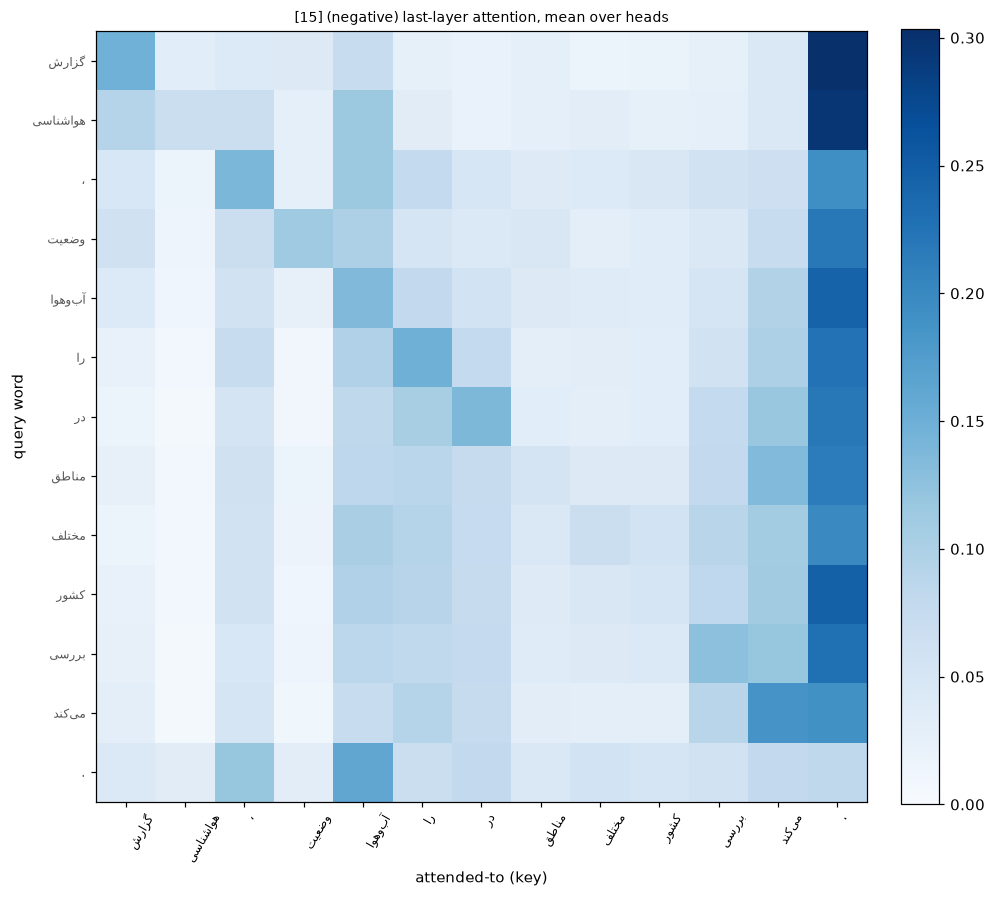

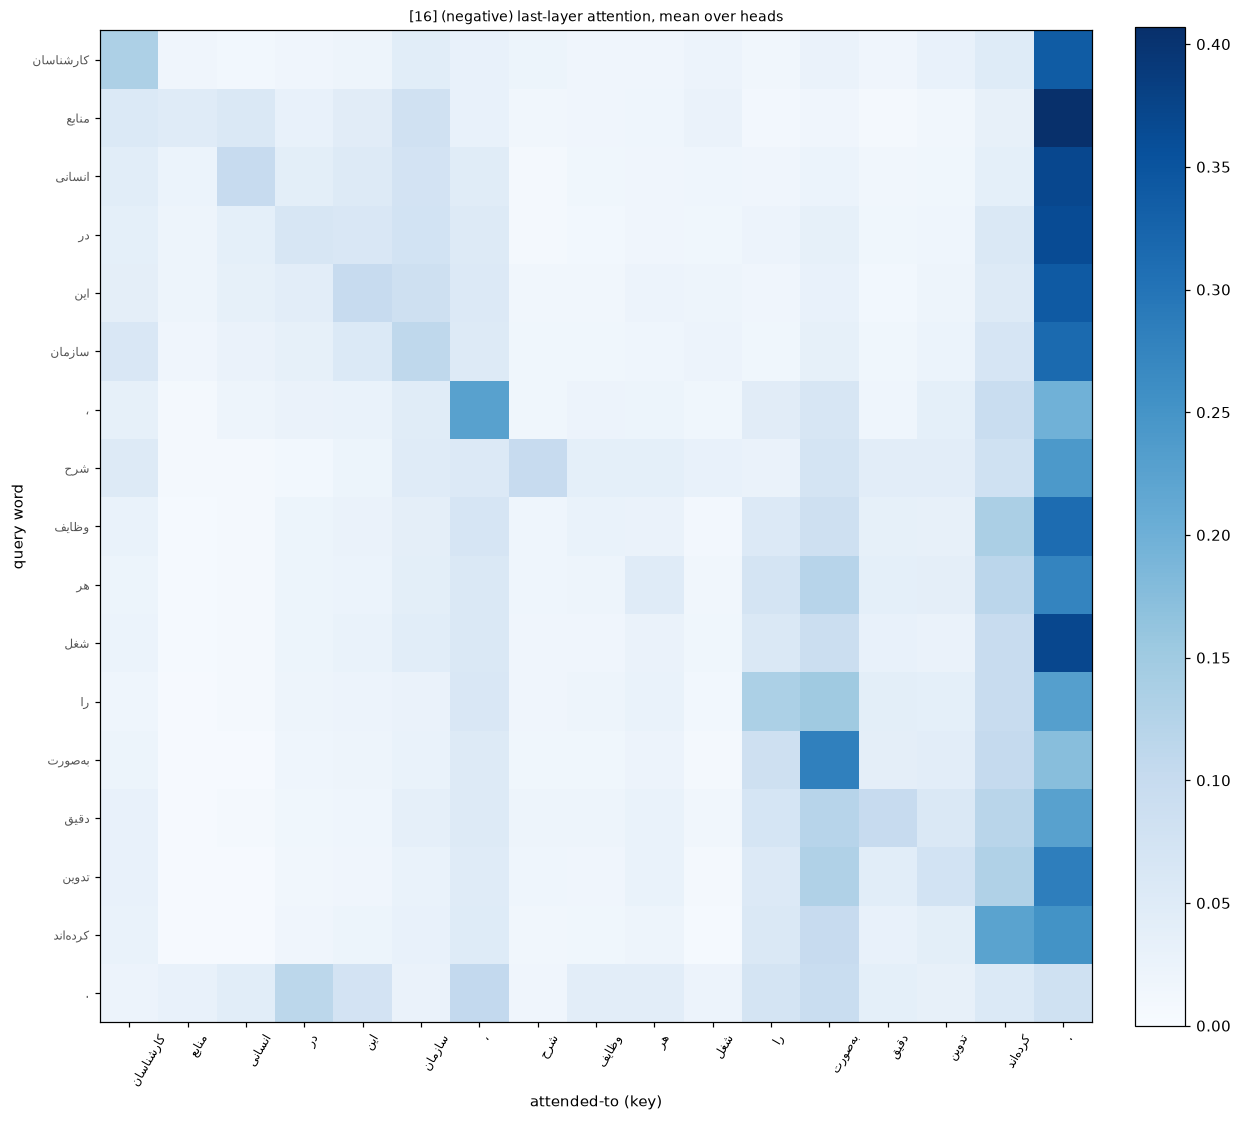

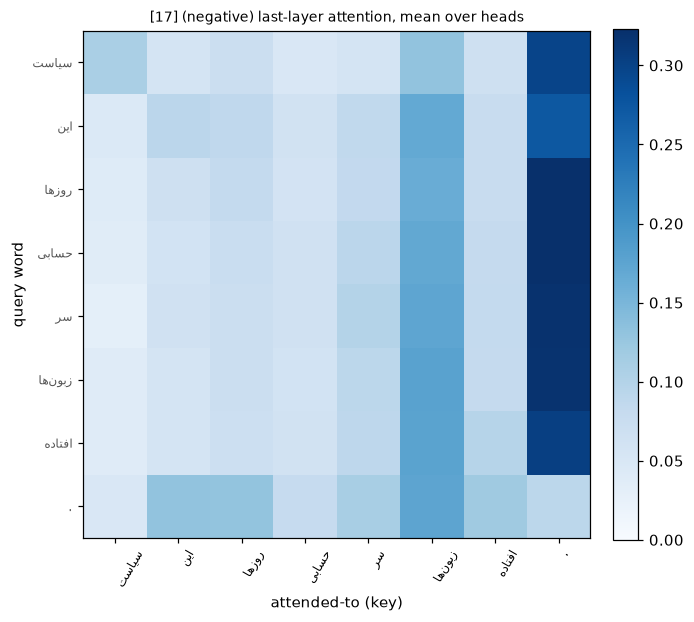

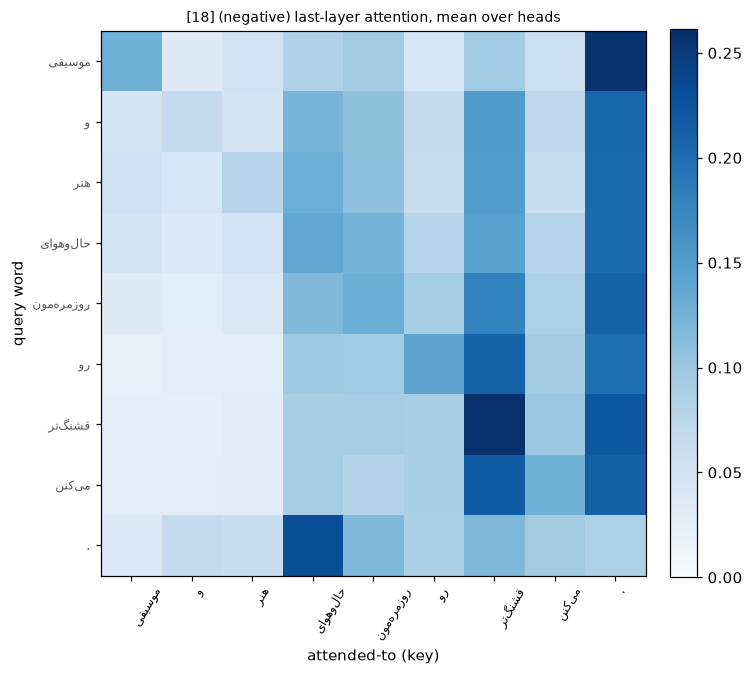

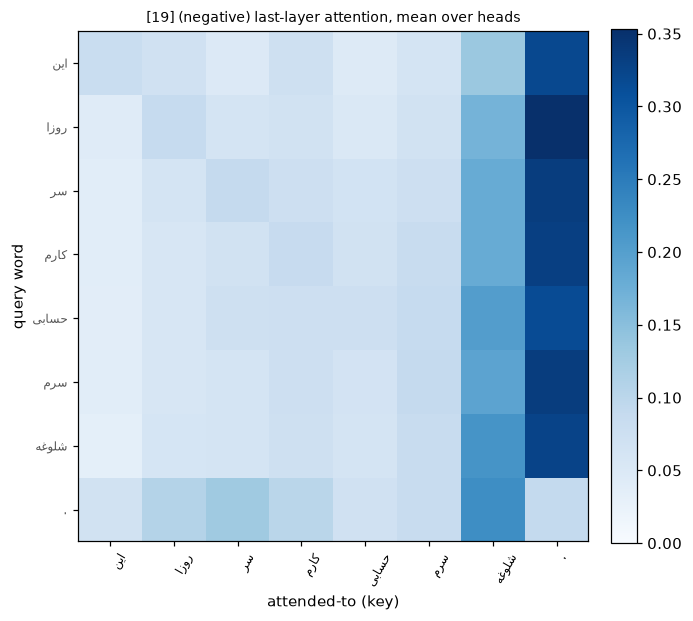

In [7]:
from span_classifier_common import SPAN_COLORS

TAG_COLORS = {"O": "#555555", "B-IF": SPAN_COLORS["IF"], "I-IF": SPAN_COLORS["IF"],
              "B-THEN": SPAN_COLORS["THEN"], "I-THEN": SPAN_COLORS["THEN"]}


def plot_attention_heatmap(r, title, ax=None):
    tokens = r["tokens"]
    attn = r["word_attn"]
    labels = [shape_for_plot(t) for t in tokens]

    show_ax = ax
    if show_ax is None:
        fig, show_ax = plt.subplots(figsize=(0.55 * len(tokens) + 2, 0.55 * len(tokens) + 2))
    im = show_ax.imshow(attn, cmap="Blues", vmin=0)
    show_ax.set_xticks(range(len(tokens)))
    show_ax.set_yticks(range(len(tokens)))
    show_ax.set_xticklabels(labels, rotation=60, ha="left", fontsize=8)
    show_ax.set_yticklabels(labels, fontsize=8)
    for tick, tag in zip(show_ax.get_yticklabels(), r["pred_tags"]):
        tick.set_color(TAG_COLORS[tag])
    show_ax.set_xlabel("attended-to (key)")
    show_ax.set_ylabel("query word")
    show_ax.set_title(title, fontsize=9)
    if ax is None:
        fig.colorbar(im, ax=show_ax, fraction=0.046, pad=0.04)
        fig.tight_layout()
        return fig
    return None


for i, r in enumerate(results):
    label = "positive" if r["gold_positive"] else "negative"
    fig = plot_attention_heatmap(r, f"[{i}] ({label}) last-layer attention, mean over heads")
    plt.show()

## Caveats

- **The sentence-final `.` dominates raw attention.** Across the positive examples above, every
  span token puts 20-75% of its last-layer attention mass on the trailing `.` token -- a well-documented
  BERT phenomenon where a fixed, low-information late-sequence token (here `.`, often `[SEP]`) acts as a
  attention "no-op" sink the model dumps unneeded mass into (see Clark et al. 2019, "What Does BERT
  Look At?"). The "top content words" reported above exclude punctuation for this reason; without that
  filter nearly every row would just read `.` and nothing else.
- **Attention is not attribution.** A high attention weight means the token's representation was mixed
  in heavily; it doesn't prove that mixing *caused* the predicted label (see Jain & Wallace 2019,
  "Attention is not Explanation"). Treat this as a diagnostic/debugging aid, not a rigorous causal
  explanation -- gradient-based methods (e.g. integrated gradients) or attention rollout across all
  layers would be a stronger next step.
- **Last layer only.** Earlier layers mix in different (often more syntactic) information; this
  notebook only inspects the layer closest to the classification head. Averaging attention rollout
  across all layers (multiplying per-layer attention matrices, as in Abnar & Zuidema 2020) would account
  for indirect, multi-hop attention paths this single-layer view misses.
- **Head-averaging hides specialization.** BERT attention heads are known to specialize (e.g. some
  heads track adjacent tokens, others track the `[SEP]`/`[CLS]` sink); averaging over heads is simple
  but can wash out a single informative head's signal. Worth a follow-up: look at per-head attention for
  the clearest examples above.
- **LoRA only touches query/value projections** (`target_modules=["query", "value"]` in
  `train_span_classifier.py`), so the attention *pattern* itself is partly adapter-driven; that's exactly
  the mechanism we're inspecting here.